In [133]:
import os
from pathlib import Path
import pandas as pd
import os
import numpy as np
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import torch

### Load Datasets

In [134]:
from pathlib import Path
base = Path(r"C:/Users/gorab/.cache/kagglehub/datasets/fhnw-i4ds/sdobenchmark/versions/4")
example_path = base / "SDOBenchmark_full"
train_path = example_path / "training"
test_path = example_path / "test"

In [ ]:
import pandas as pd
import os
import numpy as np

meta_path = os.path.join(train_path, "meta_data.csv")
flare_df = pd.read_csv(meta_path, parse_dates=["start", "end"], index_col="id")
meta_path2 = os.path.join(test_path, "meta_data.csv")
flare_df2 = pd.read_csv(meta_path2, parse_dates=["start", "end"], index_col="id")

8336

In [136]:
from torch.utils.data import Dataset
def flux_to_class(f):
        if f < 1e-7:
            return "quiet"
        elif f < 1e-6:
            return "B"
        elif f < 1e-5:
            return "C"
        elif f < 1e-4:
            return "M"
        else:
            return "X"

# Dataset loader datastructure
class SolarDataset(Dataset):
    def __init__(self, df, root, transform=None, mode="sequence", max_samples = 500):
        self.df = df
        self.root = root
        self.transform = transform
        self.mode = mode
        self.max_samples = max_samples
        self.class_map = {"quiet": 0, "B": 1, "C": 2, "M": 3, "X": 4}

        self.valid_indices = []

        # for all the data
        for i in range(len(df)):

            # get the row and sample id
            row = df.iloc[i]
            sample_id = row.name

            try:
                # get region and sample folders from df, 
                region, sample_folder = sample_id.split("_", 1)
                sample_path = os.path.join(root, region, sample_folder)

                # get images
                files = os.listdir(sample_path)

                # get magnetrogram images only for the time being
                mags = [f for f in files if "magnetogram" in f]

                # keep only 4-frame samples
                if len(mags) == 4:
                    self.valid_indices.append(i)

                    if self.max_samples and len(self.valid_indices) >= self.max_samples:
                        break
            except:
                continue

    def __len__(self):
        return len(self.valid_indices)

    # return images, 
    def __getitem__(self, idx):
        row = self.df.iloc[self.valid_indices[idx]]
        sample_id = row.name
        target = row["peak_flux"]
        cls = flux_to_class(target)
        cls_id = self.class_map[cls]
        region, sample_folder = sample_id.split("_", 1)
        sample_path = os.path.join(self.root, region, sample_folder)

        files = sorted(os.listdir(sample_path))
        mags = [f for f in files if "magnetogram" in f]

        imgs = []
        for f in mags:
            img = Image.open(os.path.join(sample_path, f)).convert("L")

            if self.transform:
                img = self.transform(img)

            imgs.append(img)
        if self.mode == "single":
            img = imgs[-1]  # baseline
            return img, torch.tensor(target, dtype=torch.float32), torch.tensor(cls_id)    
        elif self.mode == "sequence":
            imgs = torch.stack(imgs)
            return imgs, torch.tensor(target, dtype=torch.float32), torch.tensor(cls_id)
        else:
            raise ValueError("mode must be 'single' or 'sequence'")

In [137]:
from torchvision import transforms
# PIL image -> tensor. Needed for CNN, and torch. 
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

print("loading datasets . . .")

ms = 1000

train_sequence = SolarDataset(flare_df, train_path, transform, "sequence", max_samples=ms)

test_sequence = SolarDataset(flare_df2, test_path, transform, "sequence", max_samples=ms)

train_single = SolarDataset(flare_df, train_path, transform, "single", max_samples=ms)

test_single = SolarDataset(flare_df2, test_path, transform, "single", max_samples=ms)

loading datasets . . .


In [138]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import Subset

# extract only VALID dataset samples
sample_ids = [train_sequence.df.index[i] for i in train_sequence.valid_indices]

# get active region ids
groups = np.array([s.split("_")[0] for s in sample_ids])

# dataset indices (aligned)
indices = np.arange(len(train_sequence))

# group-aware split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
train_idx, val_idx = next(gss.split(indices, groups=groups))

# subsets
train_seq = Subset(train_sequence, train_idx)
val_seq = Subset(train_sequence, val_idx)
train_sin = Subset(train_single, train_idx)
val_sin = Subset(train_single, val_idx)


# data loaders 
train_loader = DataLoader(train_seq, batch_size=8, shuffle=True)
val_loader = DataLoader(val_seq, batch_size=8, shuffle=False)
train_loader_single = DataLoader(train_sin, batch_size=8, shuffle=True)
val_loader_single = DataLoader(val_sin, batch_size=8, shuffle=False)

# use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [139]:
import matplotlib.pyplot as plt
import torch

# reverse mapping for readability
CLASS_NAMES = {0: "quiet", 1: "B", 2: "C", 3: "M", 4: "X"}

def show_sample(dataset, idx):
    sample = dataset[idx]

    # handle both cases (with or without class)
    if len(sample) == 3:
        x, y, cls_id = sample
        cls_name = CLASS_NAMES[int(cls_id)]
    else:
        x, y = sample
        cls_name = "N/A"

    # --- SEQUENCE CASE ---
    if x.dim() == 4:  # [T, C, H, W]
        T = x.shape[0]
        fig, axes = plt.subplots(1, T, figsize=(3*T, 3))

        if T == 1:
            axes = [axes]

        for i in range(T):
            axes[i].imshow(x[i].squeeze(), cmap="gray")
            axes[i].set_title(f"t{i+1}")
            axes[i].axis("off")

    # --- SINGLE IMAGE CASE ---
    elif x.dim() == 3:  # [C, H, W]
        fig, ax = plt.subplots(1, 1, figsize=(3, 3))
        ax.imshow(x.squeeze(), cmap="gray")
        ax.set_title("single frame")
        ax.axis("off")

    else:
        raise ValueError("Unexpected input shape")

    # title with both regression + class
    plt.suptitle(
        f"peak_flux = {y.item():.2e} | class = {cls_name}",
        fontsize=12
    )

    plt.tight_layout()
    plt.show()

printing example sample!


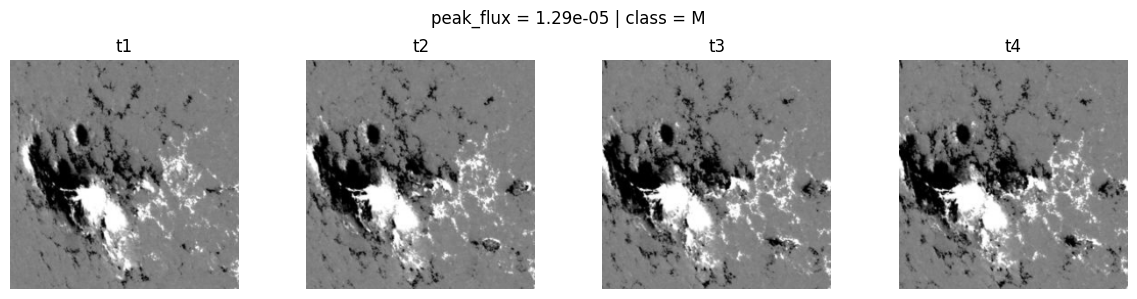

In [140]:
import random
idx = random.randint(0, len(train_sequence)-1)
print("printing example sample!")
show_sample(train_sequence, idx)

In [141]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 1 in channel, 16 out, 3 x 3 kernel size, padding
        self.conv1 = nn.Conv2d(1, 16, 3, padding=0)
        # second later, 16 in, 32 out, 3 x3 kernel size, padding
        self.conv2 = nn.Conv2d(16, 32, 3, padding=0)
        # down sampling 224 -> 112 -> 56
        # keeps strongest features, reduces computation
        self.pool = nn.MaxPool2d(2)
        # adaptive average pooling, forces output feature map to be exactly 8x8
        # output size depends on input resolution, fully connected layer would break
        # basically, model adapts to image size so stuff doesn't break
        self.adapt = nn.AdaptiveAvgPool2d((8, 8))
        # fully connected layer : 32 channels * 8 x 8 (fully flatten feature map)
        # maps it to 64 dimensional vector
        # spatial feature -> abstract representation
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        # maps 64 features to single scalar, the predicted peak_flux
        self.fc2 = nn.Linear(64, 1)
    def forward_features(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.adapt(x)
        x = x.view(x.size(0), -1)
        return x
    def forward(self, x):
        x = self.forward_features(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x[:, 0]

In [142]:
# imput: B (batch size), T (number of frames), F (number of features)
class TemporalAttention(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        self.attn = nn.Linear(feature_dim, 1)
    def forward(self, x):
        # x: [B, T, F]
        # compute attention scores
        weights = self.attn(x)  
        # normalize with softmax, weights sum to 1 accross time     
        weights = torch.softmax(weights, dim=1)
        # weighted sum - temporal aggregation. 
        out = (x * weights).sum(dim=1)  # weighted sum
        return out, weights
# 4 images -> CNN -> 4 feature vectors -> attention -> weighted combination -> prediction
class AttentionTemporalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # use frame CNN to encode frames
        self.encoder = BaselineCNN()
        # use temporal attention
        self.attention = TemporalAttention(32 * 8 * 8)
        self.head = nn.Sequential(
            nn.Linear(32 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.reshape(B * T, C, H, W)
        features = self.encoder.forward_features(x)
        features = features.reshape(B, T, -1)
        fused, attn_weights = self.attention(features)
        out = self.head(fused).squeeze(-1)

        return out, attn_weights.squeeze(-1)

In [143]:
class FrameDiffModel(nn.Module):
    def __init__(self, base_cnn):
        super().__init__()
        self.cnn = base_cnn

        self.head = nn.Sequential(
            nn.Linear(4 * 2048, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape

        # flatten time into batch
        x = x.view(B * T, C, H, W)   # ✅ FIX

        features = self.cnn.forward_features(x)  # [B*T, 2048]
        features = features.view(B, T, -1)       # [B, T, 2048]

        f1, f2, f3, f4 = features[:, 0], features[:, 1], features[:, 2], features[:, 3]

        d1 = f2 - f1
        d2 = f3 - f2
        d3 = f4 - f3

        feats = torch.cat([f4, d1, d2, d3], dim=1)

        out = self.head(feats).squeeze(-1)

        return out

In [145]:
print("loading current models . . .")
baseline_model = BaselineCNN()
baseline_model.load_state_dict(torch.load('baseline_3.pth', weights_only=True))
print("loaded current baseline model")
temp_model = AttentionTemporalCNN().to(device)
temp_model.load_state_dict(torch.load("attention_2.pth", map_location=device))
print("loaded current temporal attention model")
encoder = BaselineCNN().to(device)
diffmodel = FrameDiffModel(encoder).to(device)
diffmodel.load_state_dict(torch.load("framediff_model_2.pth"))
print("loaded current frame-difference model")

loading current models . . .
loaded current baseline model
loaded current temporal attention model
loaded current frame-difference model


In [146]:
import math

baseline_model.eval()

baseline_errors = []
samples = []

with torch.no_grad():
    for i in range(len(val_sin)):
        x, y, _ = val_sin[i]
        # baseline = SINGLE FRAME ONLY
        x_in = x.unsqueeze(0).to(device).float()
        y_val = float(y)
        pred = baseline_model(x_in).item()
        # safety checks
        if math.isnan(pred) or math.isnan(y_val):
            continue
        err = abs(pred - y_val)
        baseline_errors.append(err)
        samples.append((i, x, y_val, pred))

In [147]:
temp_model.eval()
temporal_errors = []
samples = []
with torch.no_grad():
    for i in range(len(val_seq)):
        x, y, _ = val_seq[i]

        # x: [T, C, H, W] → add batch dim → [1, T, C, H, W]
        x_in = x.unsqueeze(0).to(device).float()
        y_val = float(y)

        preds, attn = temp_model(x_in)
        pred = preds.item()

        # safety checks
        if math.isnan(pred) or math.isnan(y_val):
            continue

        err = abs(pred - y_val)

        temporal_errors.append(err)
        samples.append((i, x, y_val, pred, attn.cpu()))

In [151]:
diffmodel.eval()
diff_errors = []
samples = []
with torch.no_grad():
    for i in range(len(val_seq)):
        x, y, _ = val_seq[i]

        # x: [T, C, H, W] → [1, T, C, H, W]
        x_in = x.unsqueeze(0).to(device).float()
        y_val = float(y)

        # diffmodel has NO attention
        pred = diffmodel(x_in).item()

        # safety checks
        if math.isnan(pred) or math.isnan(y_val):
            continue

        err = abs(pred - y_val)

        diff_errors.append(err)
        samples.append((i, x, y_val, pred))

In [158]:
import numpy as np
import matplotlib.pyplot as plt

def summarize_errors(errors, name, bins=30):
    print(f"\n{'='*10} {name} Error Summary {'='*10}")

    errors = np.array(errors)

    # Summary statistics
    mean = errors.mean()
    std = errors.std()
    median = np.median(errors)
    p90 = np.percentile(errors, 90)
    p95 = np.percentile(errors, 95)
    p99 = np.percentile(errors, 99)
    max_err = errors.max()
    min_err = errors.min()

    print(f"Mean      : {mean:.6e}")
    print(f"Std       : {std:.6e}")
    print(f"Median    : {median:.6e}")
    print(f"90th pct  : {p90:.6e}")
    print(f"95th pct  : {p95:.6e}")
    print(f"99th pct  : {p99:.6e}")
    print(f"Min       : {min_err:.6e}")
    print(f"Max       : {max_err:.6e}")

    # Plot
    plt.figure(figsize=(6, 4))
    plt.hist(errors, bins=bins, edgecolor="black", alpha=0.75)

    plt.title(f"Error Distribution: {name}")
    plt.xlabel("Absolute Error")
    plt.ylabel("Frequency")

    # Add vertical reference lines for key stats
    plt.axvline(mean, color="red", linestyle="--", label="Mean")
    plt.axvline(median, color="green", linestyle="--", label="Median")

    plt.legend()
    plt.tight_layout()
    plt.show()


========== Baseline Error Summary ==========
Mean      : 3.775358e-04
Std       : 2.002524e-04
Median    : 3.741742e-04
90th pct  : 6.082751e-04
95th pct  : 6.607283e-04
99th pct  : 8.984453e-04
Min       : 5.389414e-06
Max       : 1.187335e-03


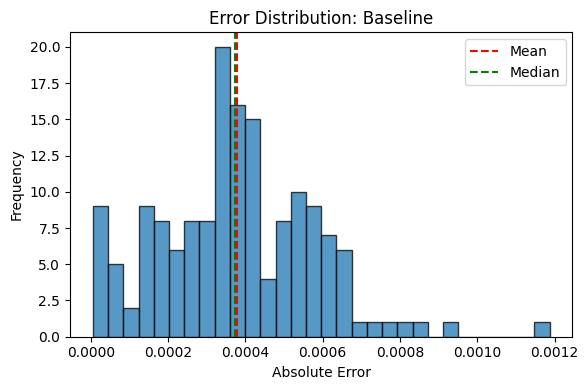


========== Temporal Attention Error Summary ==========
Mean      : 2.308969e-03
Std       : 2.737870e-04
Median    : 2.343578e-03
90th pct  : 2.629969e-03
95th pct  : 2.677104e-03
99th pct  : 2.791873e-03
Min       : 1.388763e-03
Max       : 2.878384e-03


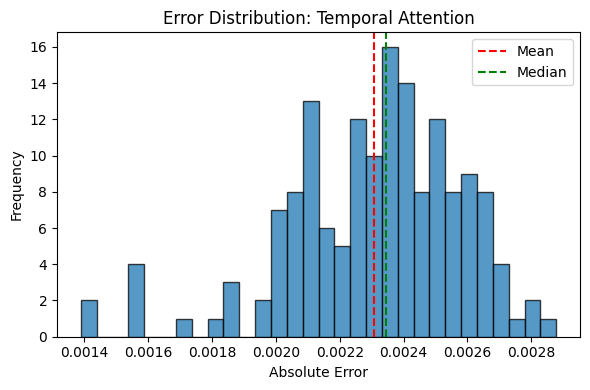


========== Temporal Difference Error Summary ==========
Mean      : 1.242484e-04
Std       : 7.164335e-06
Median    : 1.235117e-04
90th pct  : 1.328741e-04
95th pct  : 1.374231e-04
99th pct  : 1.419920e-04
Min       : 1.061712e-04
Max       : 1.568920e-04


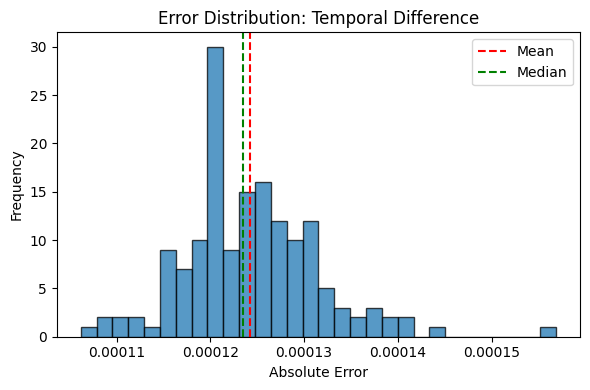

In [159]:
summarize_errors(baseline_errors, "Baseline")
summarize_errors(temporal_errors, "Temporal Attention")
summarize_errors(diff_errors, "Temporal Difference")

In [95]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x):
        self.model.eval()

        output = self.model(x)

        # if model returns tuple (pred, attn)
        if isinstance(output, tuple):
            output = output[0]

        self.model.zero_grad()
        output.backward(torch.ones_like(output))

        grads = self.gradients           # [B, C, H, W]
        acts = self.activations          # [B, C, H, W]

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1)

        cam = F.relu(cam)

        # normalize
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam

def show_gradcam(model, dataset, idx, device):
    x, y, z = dataset[idx]
    x = x.unsqueeze(0).to(device).float()  # [1, C, H, W]

    cam_extractor = GradCAM(model, model.conv2)

    cam = cam_extractor(x)  # [1, H_cam, W_cam]

    # 🔧 FIX: upsample CAM to match input image size
    cam = F.interpolate(
        cam.unsqueeze(1),                 # [B, 1, H, W]
        size=x.shape[-2:],                # match (H, W) of input
        mode='bilinear',
        align_corners=False
    ).squeeze(1)                          # back to [B, H, W]

    img = x.squeeze().cpu().detach().numpy()
    heatmap = cam[0].cpu().detach().numpy()

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.title("Input Image")
    plt.imshow(img, cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Grad-CAM")
    plt.imshow(img, cmap="gray")
    plt.imshow(heatmap, cmap="jet", alpha=0.5)
    plt.axis("off")

    plt.suptitle(f"peak_flux = {y:.2e}")
    plt.show()


printing grad-cam example: 


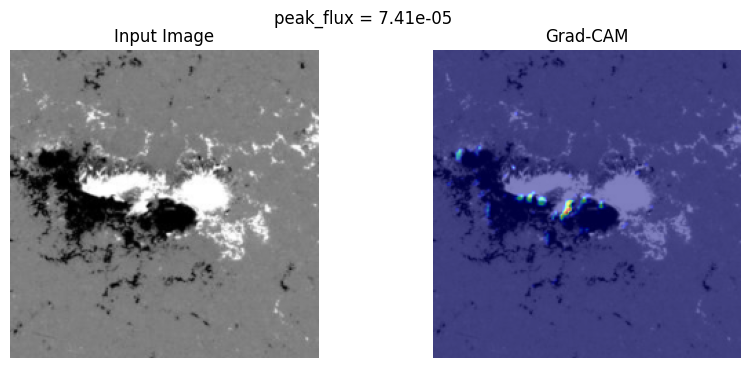

In [157]:
print("printing grad-cam example: ")
idx = random.randint(0, len(train_sequence)-1)
show_gradcam(baseline_model, train_single, idx=idx, device=device)